# Analysis of Missing and Traced Women Cases in India (2017–2021)

This project analyzes the number of missing and traced women cases
across different states in India from 2017 to 2021.

The objective of this project is to identify trends across years,
compare state-wise patterns, and examine tracing success rates.

## Importing Libraries

In [1]:
import plotly.express as px
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mplcursors
import  re

## Loadind Dataset

In [3]:
df=pd.read_csv("Missing_Women_Analysis.csv")
df


,Sl. No.,State/UT,2017 - Missing,2017 - Traced,2018 - Missing,2018 - Traced,2019 - Missing,2019 - Traced,2020 - Missing,2020 - Traced,2021 - Missing,2021 - Traced
0,1,Andhra Pradesh,5225.0,6423.0,5792.0,6042.0,6896.0,6583.0,7576,7195,10085,9616
1,2,Arunachal Pradesh,90.0,96.0,12.0,96.0,43.0,44.0,9,9,2,2
2,3,Assam,2302.0,2314.0,4087.0,3448.0,3330.0,3116.0,2714,3963,3178,2846
3,4,Bihar,6020.0,3561.0,7775.0,7570.0,8453.0,5783.0,6287,5831,6144,6748
4,5,Chhattisgarh,7383.0,6501.0,9412.0,8645.0,11108.0,9388.0,9113,8749,12109,10473
5,6,Goa,274.0,254.0,234.0,214.0,297.0,251.0,190,254,225,216
6,7,Gujarat,7712.0,8481.0,9246.0,8570.0,9268.0,8543.0,8290,7753,9812,10608
7,8,Haryana,4780.0,5003.0,5311.0,6085.0,7659.0,6885.0,6698,6434,8863,7813
8,9,Himachal Pradesh,852.0,881.0,1179.0,1011.0,1356.0,1259.0,1095,1147,1587,1651
9,10,Jharkhand,361.0,469.0,399.0,333.0,437.0,477.0,408,483,494,479


## Dataset Overview

### What does the dataset contain?
- How many rows and columns are there?
  
- What are the column names and data types?

- Are there any missing values?

In [4]:
#no.of rows & columns
print("Shape :",df.shape)
print()

Shape : (39, 12)



In [6]:
#Columns and their datatypes
print("Columns with their datatypes :\n",df.dtypes)


Columns with their datatypes :
 Sl. No.            object
State/UT           object
2017 - Missing    float64
2017 - Traced     float64
2018 - Missing    float64
2018 - Traced     float64
2019 - Missing    float64
2019 - Traced     float64
2020 - Missing      int64
2020 - Traced       int64
2021 - Missing      int64
2021 - Traced       int64
dtype: object


In [7]:
#Checking NaN values
df.isna().sum()

Sl. No.           0
State/UT          0
2017 - Missing    1
2017 - Traced     1
2018 - Missing    1
2018 - Traced     1
2019 - Missing    1
2019 - Traced     1
2020 - Missing    0
2020 - Traced     0
2021 - Missing    0
2021 - Traced     0
dtype: int64

#### Observation:
- The dataset has 39 rows and 12 columns.
  
- Missing values found in 6 columns: ('2017 - Missing','12017 - Traced','2018 - Missing','2018 - Traced','2019 - Missing','2019 - Traced')

## Data Cleaning
### Is the data clean and ready for analysis?
- Are there duplicates?
  
- Are categorical values standardized?

- Are all column names clean and standardized?

- Are there NaN values?
  

In [8]:
#Checking duplicates
has_duplicates=df.duplicated().any()
if has_duplicates==True:
    df=df.drop_duplicates()
else:
    print("No duplicate values")


No duplicate values


In [9]:
# standerdizing column names
df.columns = [re.sub('_+', '_', re.sub(r'[\s-]+', '_', col.strip())) for col in df.columns]

#converting to lowercase for consistency
df.columns = [col.lower() for col in df.columns]

#cleaned column names
print("Cleaned column names :\n",df.columns.tolist())


Cleaned column names :
 ['sl._no.', 'state/ut', '2017_missing', '2017_traced', '2018_missing', '2018_traced', '2019_missing', '2019_traced', '2020_missing', '2020_traced', '2021_missing', '2021_traced']


In [10]:
#states with NaN values
nan_states = df.loc[df.isna().any(axis=1), 'state/ut'].unique()
print(f"{nan_states} has NaN values")

['Ladakh'] has NaN values


#### Observation

- No duplicates values are there in dataset.
  
- Column standardization is done

- Only Ladakh has NaN values

### Filling NaN values & dropping unnecessary column
  
- Are all numeric values in integer format?

- Is there need to drop/add any column?

-  Fill NaN values.


In [11]:
#converting datatype of numeric values to int64
num_cols = df.select_dtypes(include='number').columns
df[num_cols] = df[num_cols].astype('Int64')

print("Columns with their datatypes :\n",df.dtypes)
print()


Columns with their datatypes :
 sl._no.         object
state/ut        object
2017_missing     Int64
2017_traced      Int64
2018_missing     Int64
2018_traced      Int64
2019_missing     Int64
2019_traced      Int64
2020_missing     Int64
2020_traced      Int64
2021_missing     Int64
2021_traced      Int64
dtype: object



In [12]:
#deleting sl.no column
df=df.drop('sl._no.',axis=1)
df.head()

,state/ut,2017_missing,2017_traced,2018_missing,2018_traced,2019_missing,2019_traced,2020_missing,2020_traced,2021_missing,2021_traced
0,Andhra Pradesh,5225,6423,5792,6042,6896,6583,7576,7195,10085,9616
1,Arunachal Pradesh,90,96,12,96,43,44,9,9,2,2
2,Assam,2302,2314,4087,3448,3330,3116,2714,3963,3178,2846
3,Bihar,6020,3561,7775,7570,8453,5783,6287,5831,6144,6748
4,Chhattisgarh,7383,6501,9412,8645,11108,9388,9113,8749,12109,10473


In [13]:
missing_cols = ['2017_missing','2018_missing','2019_missing','2020_missing','2021_missing']

traced_cols = ['2017_traced','2018_traced','2019_traced','2020_traced','2021_traced']

df['total_missing']=df[missing_cols].sum(axis=1)

df['total_traced']=df[traced_cols].sum(axis=1)
df.head(2)

,state/ut,2017_missing,2017_traced,2018_missing,2018_traced,2019_missing,2019_traced,2020_missing,2020_traced,2021_missing,2021_traced,total_missing,total_traced
0,Andhra Pradesh,5225,6423,5792,6042,6896,6583,7576,7195,10085,9616,35574,35859
1,Arunachal Pradesh,90,96,12,96,43,44,9,9,2,2,156,247


In [14]:
df = df.drop([28,37,38]).reset_index(drop=True)
df

,state/ut,2017_missing,2017_traced,2018_missing,2018_traced,2019_missing,2019_traced,2020_missing,2020_traced,2021_missing,2021_traced,total_missing,total_traced
0,Andhra Pradesh,5225,6423,5792,6042,6896,6583,7576,7195,10085,9616,35574,35859
1,Arunachal Pradesh,90,96,12,96,43,44,9,9,2,2,156,247
2,Assam,2302,2314,4087,3448,3330,3116,2714,3963,3178,2846,15611,15687
3,Bihar,6020,3561,7775,7570,8453,5783,6287,5831,6144,6748,34679,29493
4,Chhattisgarh,7383,6501,9412,8645,11108,9388,9113,8749,12109,10473,49125,43756
5,Goa,274,254,234,214,297,251,190,254,225,216,1220,1189
6,Gujarat,7712,8481,9246,8570,9268,8543,8290,7753,9812,10608,44328,43955
7,Haryana,4780,5003,5311,6085,7659,6885,6698,6434,8863,7813,33311,32220
8,Himachal Pradesh,852,881,1179,1011,1356,1259,1095,1147,1587,1651,6069,5949
9,Jharkhand,361,469,399,333,437,477,408,483,494,479,2099,2241


In [15]:
#Starting index from 1.
df.index=range(1,len(df)+1)
df

,state/ut,2017_missing,2017_traced,2018_missing,2018_traced,2019_missing,2019_traced,2020_missing,2020_traced,2021_missing,2021_traced,total_missing,total_traced
1,Andhra Pradesh,5225,6423,5792,6042,6896,6583,7576,7195,10085,9616,35574,35859
2,Arunachal Pradesh,90,96,12,96,43,44,9,9,2,2,156,247
3,Assam,2302,2314,4087,3448,3330,3116,2714,3963,3178,2846,15611,15687
4,Bihar,6020,3561,7775,7570,8453,5783,6287,5831,6144,6748,34679,29493
5,Chhattisgarh,7383,6501,9412,8645,11108,9388,9113,8749,12109,10473,49125,43756
6,Goa,274,254,234,214,297,251,190,254,225,216,1220,1189
7,Gujarat,7712,8481,9246,8570,9268,8543,8290,7753,9812,10608,44328,43955
8,Haryana,4780,5003,5311,6085,7659,6885,6698,6434,8863,7813,33311,32220
9,Himachal Pradesh,852,881,1179,1011,1356,1259,1095,1147,1587,1651,6069,5949
10,Jharkhand,361,469,399,333,437,477,408,483,494,479,2099,2241


In [16]:
# Get numeric columns
num_cols = df.select_dtypes(include='number').columns

# Mask for Ladakh
mask = df['state/ut'] == 'Ladakh'

# Fill NaN using rounded row mean
df.loc[mask, num_cols] = df.loc[mask, num_cols].apply(
    lambda row: row.fillna(round(row.mean())), axis=1)

df[df['state/ut']=='Ladakh']

,state/ut,2017_missing,2017_traced,2018_missing,2018_traced,2019_missing,2019_traced,2020_missing,2020_traced,2021_missing,2021_traced,total_missing,total_traced
34,Ladakh,8,8,8,8,8,8,8,6,5,6,13,12


#### Observation

- Converted all numeric data to int.
  
- Dropped sl.no unnecessary column.

- Index started from 1.

- Filled NaN values of Ladakh to average of missing number of women in other years.

## Exploratory Data Analysis (EDA) 
### How have missing women cases changed over the years(2017-2021)?

  - What is the total number of missing women cases for each year(2017-2021)?
    
  - What is the total number of traced women cases for each year?)

      

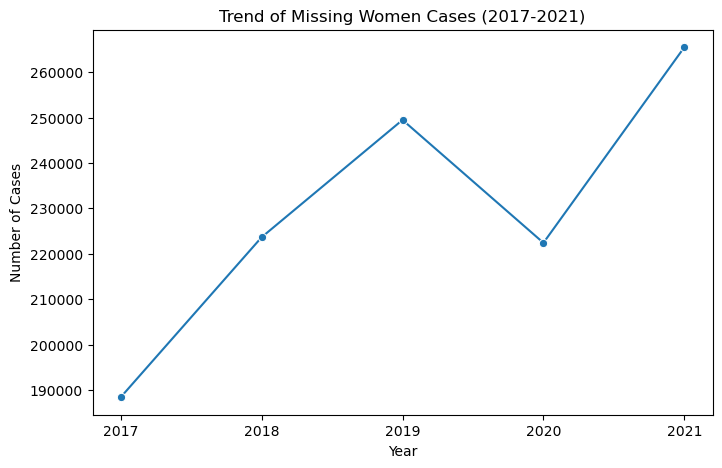

In [24]:
years = ['2017','2018','2019','2020','2021']

missing = [df[f'{year}_missing'].sum() for year in years]

plt.figure(figsize=(8,5))
sns.lineplot(x=years, y=missing, marker='o')

plt.title("Trend of Missing Women Cases (2017-2021)")
plt.xlabel("Year")
plt.ylabel("Number of Cases")

plt.show()

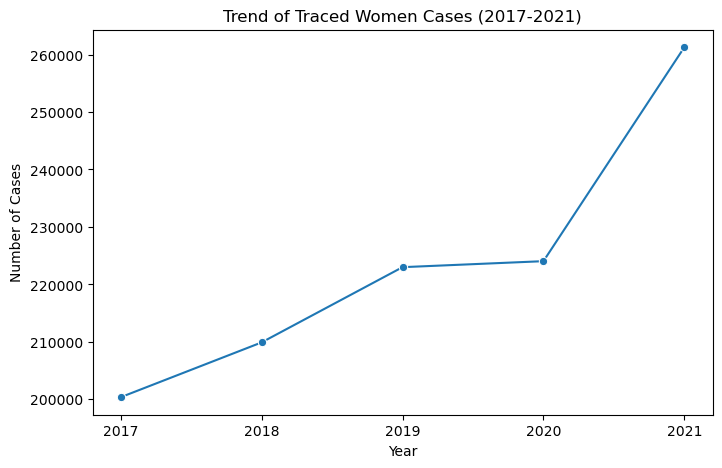

In [29]:
years = ['2017','2018','2019','2020','2021']

traced = [df[f'{year}_traced'].sum() for year in years]

plt.figure(figsize=(8,5))
sns.lineplot(x=years, y=traced, marker='o')

plt.title("Trend of Traced Women Cases (2017-2021)")
plt.xlabel("Year")
plt.ylabel("Number of Cases")

plt.show()

#### Observation

### Missing vs Traced Comparison
 - How do missing and traced women cases compare across different years?

 - Which year recorded the highest number of missing women cases?


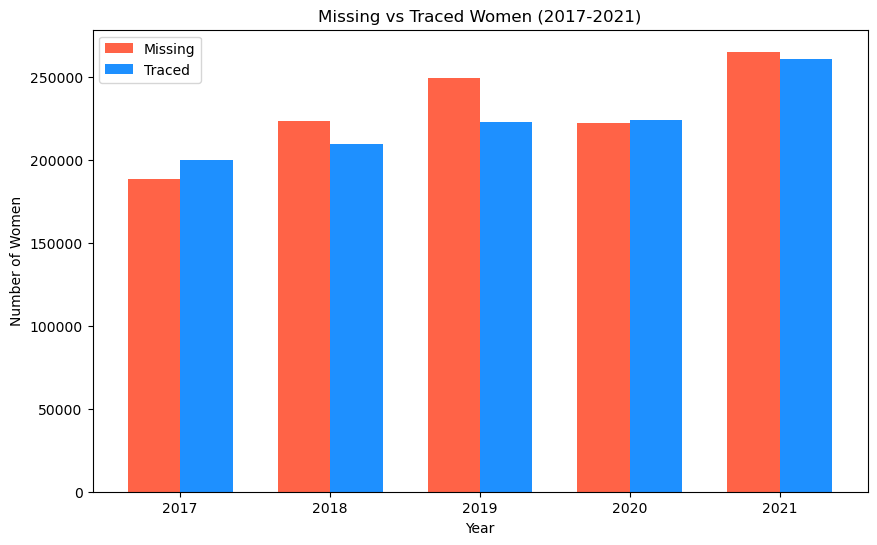

In [19]:
# Sample column list
years = ['2017','2018','2019','2020','2021']

# Sum missing and traced per year
missing = [df[f'{year}_missing'].sum() for year in years]
traced  = [df[f'{year}_traced'].sum() for year in years]

x = np.arange(len(years))  # the label locations
width = 0.35  # width of bars

fig, ax = plt.subplots(figsize=(10,6))
rects1 = ax.bar(x - width/2, missing, width, label='Missing',color="#FF6347")
rects2 = ax.bar(x + width/2, traced, width, label='Traced',color="#1E90FF")

ax.set_xlabel('Year')
ax.set_ylabel('Number of Women')
ax.set_title('Missing vs Traced Women (2017-2021)')
ax.set_xticks(x)
ax.set_xticklabels(years)
ax.legend()

plt.show()

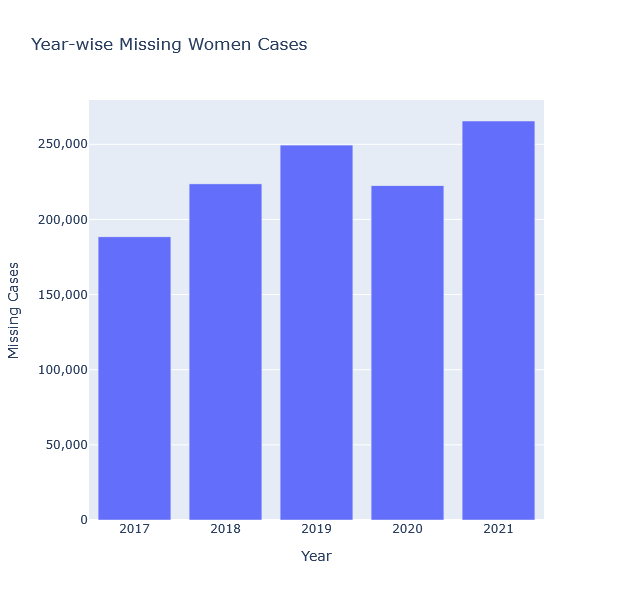

In [17]:
year_missing=df[missing_cols].sum()

fig = px.bar(
    x=year_missing.index.str.replace('_missing',''),
    y=year_missing.values,
    labels={'x': 'Year', 'y': 'Missing Cases'},
    title="Year-wise Missing Women Cases",
    height=600
)
fig.update_layout(yaxis_tickformat=",")

fig.show()

#### Observation
- 2017  and 2020  are years with trAcaed numbers more than missing numbers.
- 2021 is a year with highest number of missing women cases(265,481).

### State-wise Missing Cases

- Which states/UTs report the highest number of missing women cases?

- Which states/UTs report the lowest number of missing women?

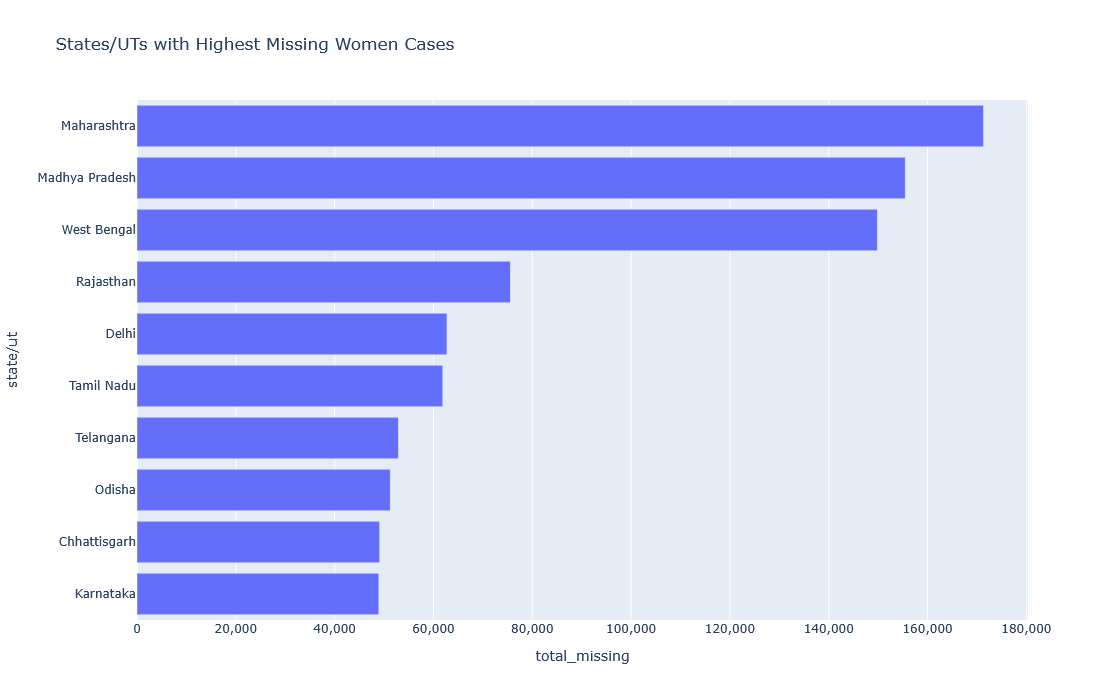

In [20]:

top_states=df.sort_values(by='total_missing',ascending=False).head(10)

fig=px.bar(
           top_states,
           x='total_missing',
           y='state/ut',
           orientation='h',
           title="States/UTs with Highest Missing Women Cases",
           height=700,
           )
fig.update_layout(
    yaxis={'categoryorder':'total ascending'},
    xaxis_tickformat=",")

fig.show()


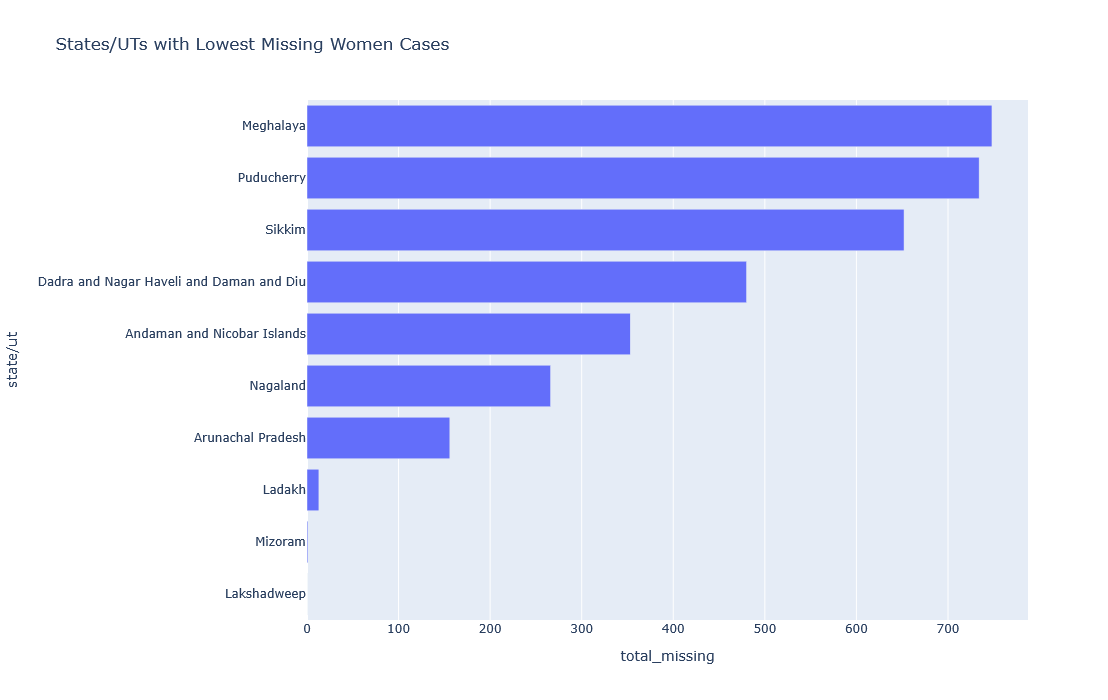

In [21]:

top_states=df.sort_values(by='total_missing',ascending=True).head(10)

fig=px.bar(
           top_states,
           x='total_missing',
           y='state/ut',
           orientation='h',
           title="States/UTs with Lowest Missing Women Cases",
           height=700,
           )
fig.update_layout(xaxis_tickformat=",")

fig.show()


#### Observation
- Maharashtra  reports the highest number of missing women cases.
- Mizoram reports the lowest number of missing women cases

### Tracing Performance by State

- Which states/UTs have the highest number of traced women cases?

- Which states have the largest gap between missing and traced cases?

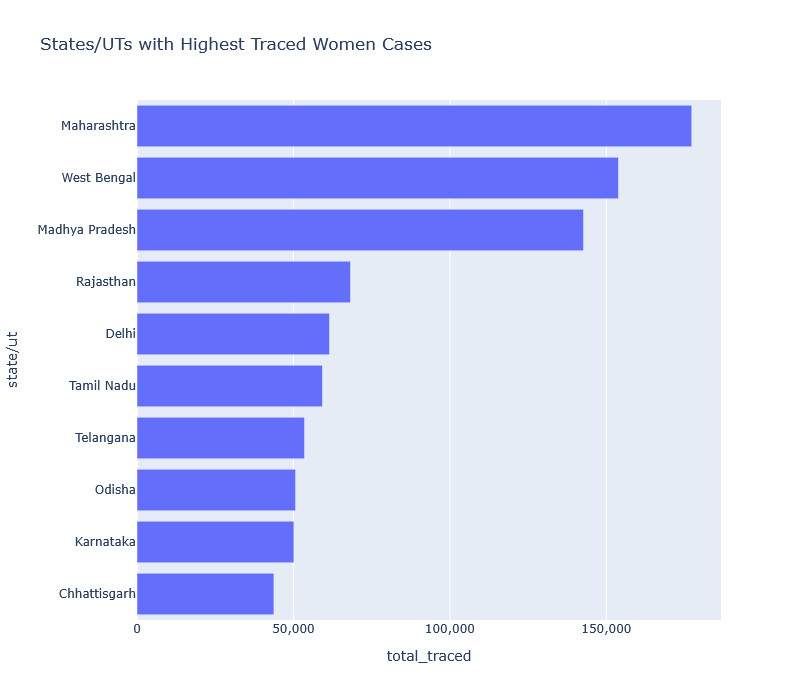

In [22]:
top_states=df.sort_values(by='total_missing',ascending=False).head(10)

fig=px.bar(
           top_states,
           x='total_traced',
           y='state/ut',
           orientation='h',
           title="States/UTs with Highest Traced Women Cases",
           height=700,
           )
fig.update_layout(
    yaxis={'categoryorder':'total ascending'},
    xaxis_tickformat=",")

fig.show()


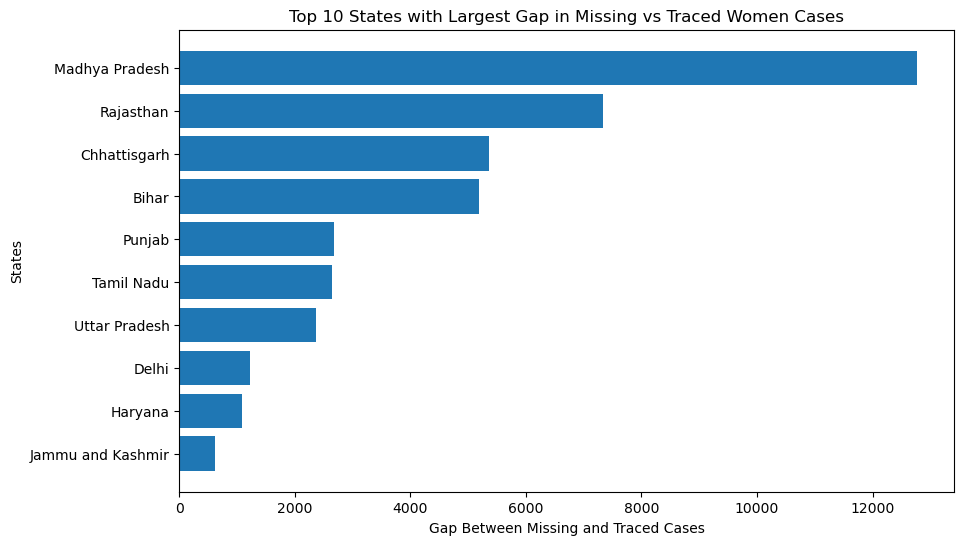

In [33]:
df['total_gap'] = df['total_missing'] - df['total_traced']

top_gap_states = df.sort_values(by='total_gap', ascending=False).head(10)

plt.figure(figsize=(10,6))

plt.barh(top_gap_states['state/ut'], top_gap_states['total_gap'])

plt.xlabel("Gap Between Missing and Traced Cases")
plt.ylabel("States")
plt.title("Top 10 States with Largest Gap in Missing vs Traced Women Cases")

plt.gca().invert_yaxis()

plt.show()

#### Observation
- Maharashtra reports the highest number oftraced  women cases.
- Madhypradesh has the largest gap between missing and traced women cases.

### Distribution Analysis

- What is the distribution of missing women cases across states?

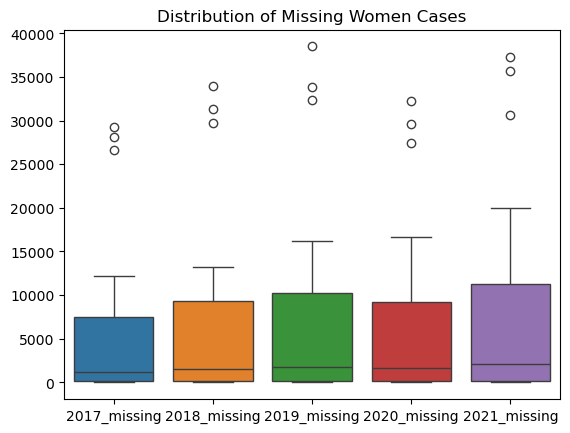

In [25]:
sns.boxplot(data=df[missing_cols])

plt.title("Distribution of Missing Women Cases")
plt.show()

#### Observation

- The box plot indicates that missing women cases generally increased from 2017 to 2021, with higher
  median values in later years.

- Several outliers appear in each year, showing that some states report significantly higher cases   c    compared to others.

- The spread of values suggests that missing cases vary widely across states, indicating regional         disparities.


###  Contribution Analysis

- Which states contribute the most to total traced cases?

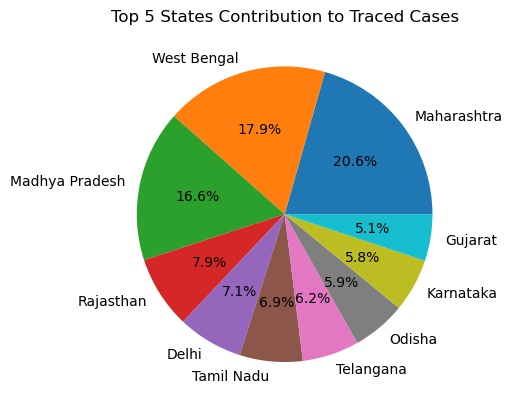

In [35]:
top = df.sort_values(by='total_traced', ascending=False).head(10)

plt.pie(top['total_traced'],
        labels=top['state/ut'],
        autopct='%1.1f%%')

plt.title("Top 5 States Contribution to Traced Cases")
plt.show()

#### Observation

- The box plot indicates that missing women cases generally increased from 2017 to 2021, with higher      median values in later years.

- Several outliers appear in each year, showing that some states report significantly higher cases       compared to others.

- The spread of values suggests that missing cases vary widely across states, indicating regional        disparities

### Pattern Detection

- How do missing cases vary across states and years?

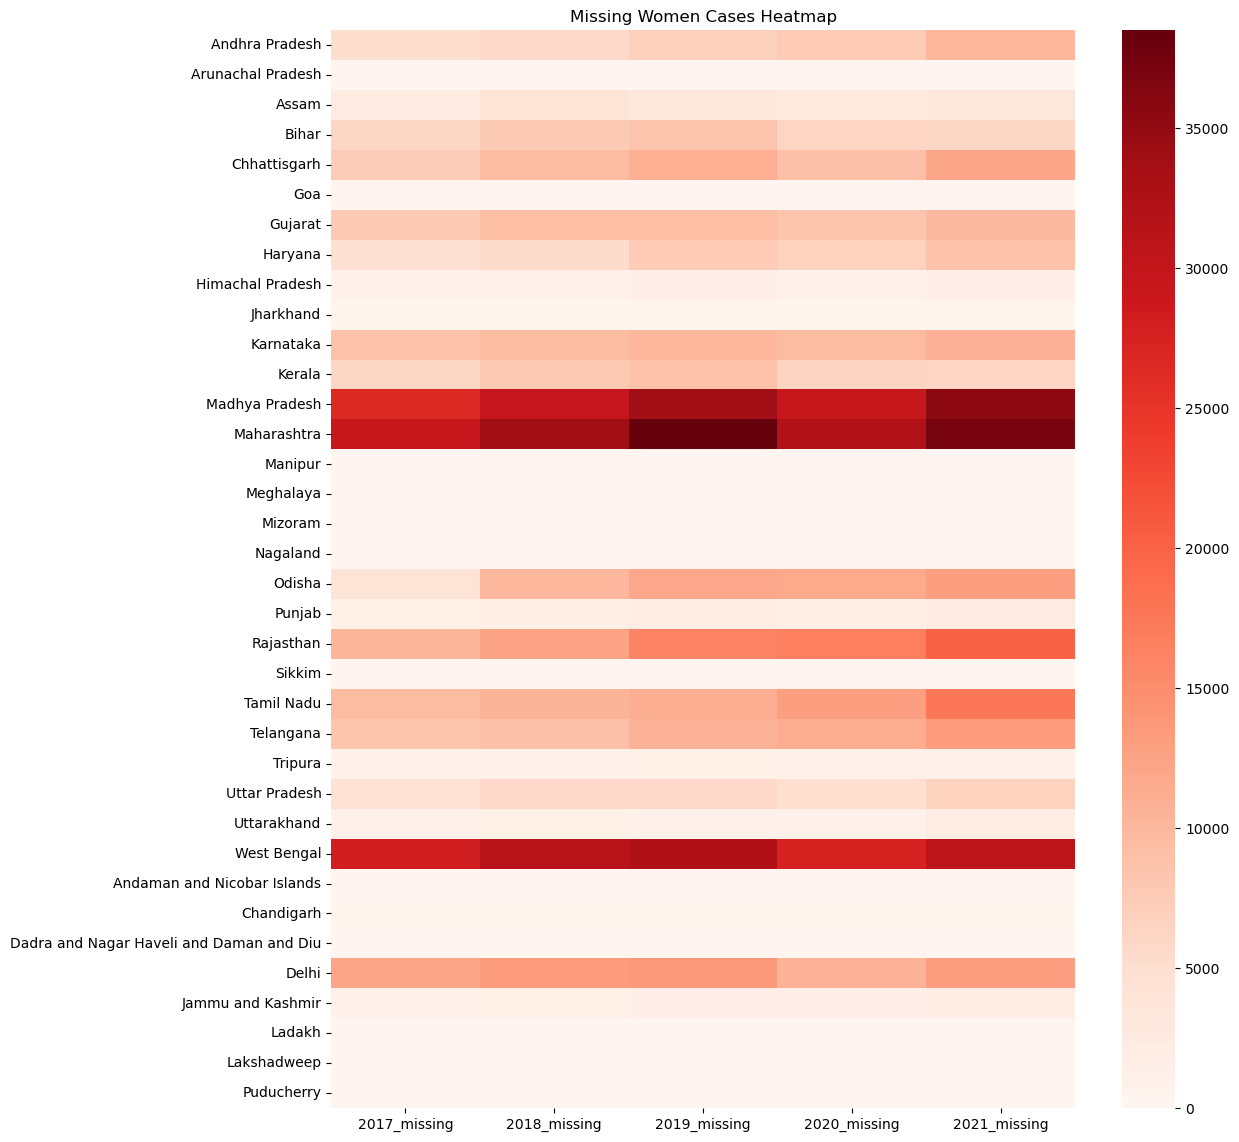

In [27]:
heat_data = df[missing_cols]

plt.figure(figsize=(12,14))

sns.heatmap(
    heat_data.astype(float),
    cmap="Reds",
    yticklabels=df['state/ut']
)

plt.title("Missing Women Cases Heatmap")

plt.show()

#### Observation

- The heatmap highlights that states like Maharashtra and West Bengal consistently report higher          numbers of missing women cases, visible through darker color intensities.

- Many smaller states and union territories show very low case numbers, represented by lighter shades.

- The visualization reveals clear regional concentration of missing cases, indicating that the issue is   more prominent in certain states.

## Key Insights

- The analysis shows that missing women cases vary significantly across states and years,      with certain states consistently reporting higher numbers.

- States such as Maharashtra and West Bengal contribute a large share of both missing and      traced cases, indicating higher reporting levels in these regions.

- Although many missing women are traced, a noticeable gap between missing and traced cases    still exists in several states, suggesting unresolved cases.

##  Interpretation

- Higher numbers in some states may be influenced by larger population sizes, urbanization,    and migration patterns.

- States with higher traced numbers may indicate better reporting systems or more effective    law enforcement efforts.

- The concentration of cases in a few regions suggests that targeted policies and preventive   measures may be required in those areas.

## Limitations of the Analysis

- The dataset covers only five years (2017–2021), which limits long-term trend analysis.

- Population differences across states are not considered, which may affect interpretation     of absolute case numbers.

- Other important factors such as socio-economic conditions, crime rates, or policing          effectiveness are not included in the dataset.




##  Conclusion

- This analysis highlights clear variations in missing women cases across states and years     in India.

- While many women are successfully traced, certain states continue to report high numbers     of missing cases, indicating areas that may require focused intervention.

- Data analysis and visualization help reveal patterns and gaps that can support better        decision-making and policy planning.